In [2]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 297
sigma = 0.226
r = 0.04
n_days = 252
n_paths = 1000
dt = 1/252
K = 300        #strike price - NEW

#generate risk-neutral paths
np.random.seed(42)
Z = np.random.standard_normal((n_paths, n_days))
daily = (r - sigma**2/2)*dt + sigma*np.sqrt(dt)*Z
price_paths = S0 *np.exp(np.cumsum(daily, axis=1))
final_prices = price_paths[:, -1]

In [3]:
def call_payoff(S_T, K):
    return np.maximum(S_T - K, 0) #not max; use array aware version

def put_payoff(S_T, K):
    return np.maximum(K - S_T, 0)

In [5]:
call_payoffs = call_payoff(final_prices, K)
put_payoffs = put_payoff(final_prices, K)

print("Call payoffs - first 10:", call_payoffs[:10].round(2))
print("Put payoffs - first 10:", put_payoffs[:10].round(2))   #first 10 to keep it readable; round to 2 dec places

Call payoffs - first 10: [  0.    29.92   0.   214.8  126.11 137.61  89.01   0.     0.    23.56]
Put payoffs - first 10: [ 2.72  0.   71.23  0.    0.    0.    0.   32.16 23.27  0.  ]


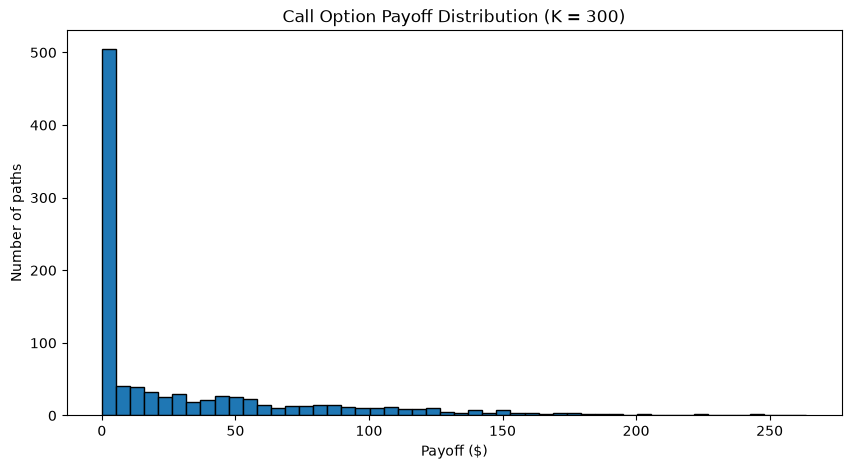

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(call_payoffs, bins=50, edgecolor="black")
plt.title("Call Option Payoff Distribution (K = 300)")
plt.xlabel("Payoff ($)")
plt.ylabel("Number of paths")
plt.show()

In [8]:
#average payoff across all risk-neutral paths
T = 1  #time to expiry in years
call_price = np.exp(-r * T) * np.mean(call_payoffs) #() discounting, shrink future avr back to today's value
put_price = np.exp(-r * T) * np.mean(put_payoffs)

print("Monte Carlo call price:", round(call_price, 2)) #avr payoff across all 1000 simulated futures(expected)
print("Monte Carlo put price: ", round(put_price, 2))

Monte Carlo call price: 30.44
Monte Carlo put price:  21.84


In [10]:
lhs = call_price - put_price #left hand side vs right / a = b/ simulation vs theory demands
rhs = S0 - K*np.exp(-r*T)
print("call - put =", round(lhs, 2))
print("S0 - K*e^(-rT) =", round(rhs, 2))

call - put = 8.6
S0 - K*e^(-rT) = 8.76
